# Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score

# Get the Data

In [3]:
df = pd.read_csv("calorie_efficiency_dataset.csv")

In [4]:
df.head()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   steps_per_day             1000000 non-null  int64  
 2   active_minutes            1000000 non-null  int64  
 3   calories_burned           1000000 non-null  int64  
 4   sleep_hours               1000000 non-null  float64
 5   hydration_liters          1000000 non-null  float64
 6   bmi                       1000000 non-null  float64
 7   workouts_per_week         1000000 non-null  int64  
 8   muscle_mass_ratio         1000000 non-null  float64
 9   body_fat_percentage       1000000 non-null  float64
 10  heart_rate_resting        1000000 non-null  float64
 11  heart_rate_avg            1000000 non-null  float64
 12  continuous_exercise_days  1000000 non-null  int64  
 13  efficiency_score          10

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,40.982084,7001.232915,69.673644,1500.0,6.500965,2.502449,24.221054,2.984637,0.350857,0.250580,65.999386,106.040468,2.431586,0.877842
std,13.550471,2482.813116,28.602711,0.0,1.196880,0.794725,5.372620,1.683523,0.077842,0.097494,5.783210,11.424947,1.685483,0.624647
min,18.000000,1000.000000,10.000000,1500.0,3.000000,0.500000,16.000000,0.000000,0.200000,0.050000,50.000000,80.000000,1.000000,0.000000
25%,29.000000,5309.000000,50.000000,1500.0,5.690000,1.960000,20.070000,2.000000,0.296000,0.182000,62.100000,98.200000,1.000000,0.552000
50%,41.000000,6993.000000,69.000000,1500.0,6.500000,2.500000,24.010000,3.000000,0.350000,0.250000,66.000000,106.000000,2.000000,0.730000
75%,53.000000,8683.000000,89.000000,1500.0,7.310000,3.040000,27.950000,4.000000,0.404000,0.317000,69.900000,113.800000,3.000000,0.991000
max,64.000000,18924.000000,180.000000,1500.0,10.000000,5.000000,40.000000,7.000000,0.600000,0.500000,90.000000,160.600000,7.000000,10.000000


# Exploratory Data Analysis


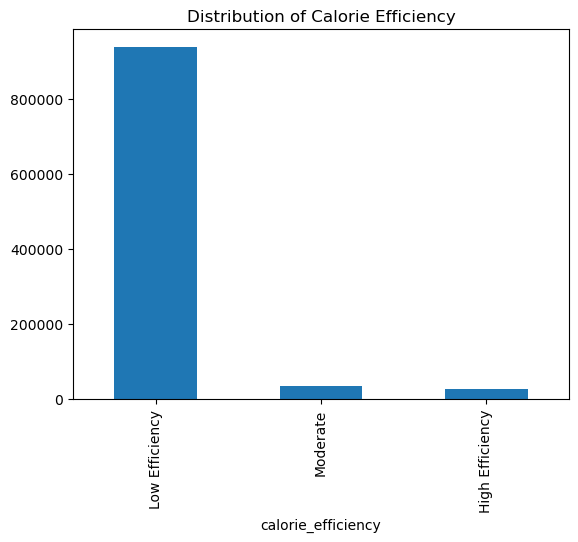

In [8]:
import matplotlib.pyplot as plt

df["calorie_efficiency"].value_counts().plot(kind="bar")
plt.title("Distribution of Calorie Efficiency")
plt.show()

<Axes: xlabel='calorie_efficiency', ylabel='steps_per_day'>

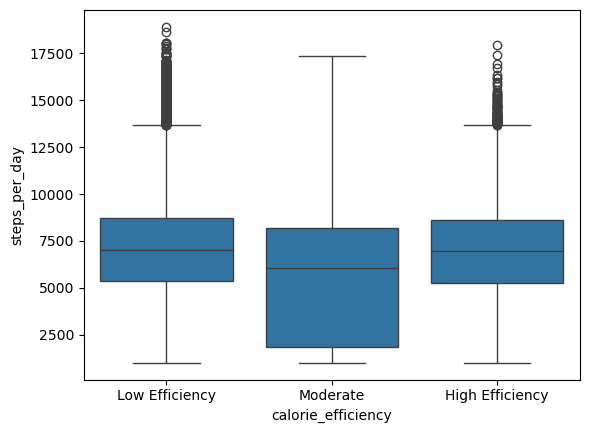

In [9]:
sns.boxplot(x="calorie_efficiency",y="steps_per_day",data=df)

# Create And Train The Model

In [10]:
X = df.drop('calorie_efficiency',axis=1)
y = df['calorie_efficiency']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Decision Tree

In [11]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# Random Forest

In [12]:
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# Prediction and Evaluation

In [28]:
predictions_dtree = dtree.predict(X_test)
print(classification_report(y_test,predictions_dtree),"\n")
print(confusion_matrix(y_test,predictions_dtree))

                 precision    recall  f1-score   support

High Efficiency       0.03      0.04      0.04      7993
 Low Efficiency       0.95      0.93      0.94    281497
       Moderate       0.20      0.25      0.22     10510

       accuracy                           0.88    300000
      macro avg       0.39      0.41      0.40    300000
   weighted avg       0.90      0.88      0.89    300000
 

[[   346   7293    354]
 [  9954 261473  10070]
 [   399   7514   2597]]


# Prediction and Evaluation

In [14]:
predictions_rdc = rfc.predict(X_test)
print(classification_report(y_test,predictions_rdc),"\n")
print(confusion_matrix(y_test,predictions_rdc))

                 precision    recall  f1-score   support

High Efficiency       0.90      0.01      0.01      7993
 Low Efficiency       0.95      1.00      0.97    281497
       Moderate       0.94      0.24      0.39     10510

       accuracy                           0.95    300000
      macro avg       0.93      0.42      0.46    300000
   weighted avg       0.95      0.95      0.93    300000
 

[[    45   7873     75]
 [     1 281411     85]
 [     4   7956   2550]]


# Decision Tree vs Random Forest

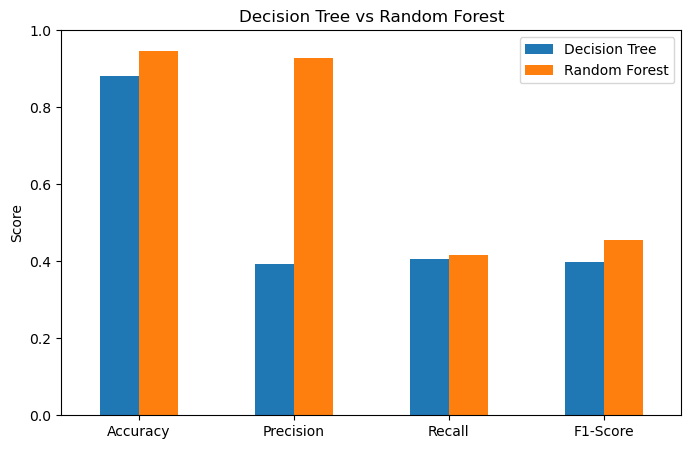

In [30]:
comparison = pd.DataFrame({
    "Decision Tree": [
        accuracy_score(y_test, predictions_dtree),
        precision_score(y_test, predictions_dtree, average="macro"),
        recall_score(y_test, predictions_dtree, average="macro"),
        f1_score(y_test, predictions_dtree, average="macro")
    ],
    "Random Forest": [
        accuracy_score(y_test, predictions_rdc),
        precision_score(y_test, predictions_rdc, average="macro"),
        recall_score(y_test, predictions_rdc, average="macro"),
        f1_score(y_test, predictions_rdc, average="macro")
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-Score"])

comparison.plot(kind="bar", figsize=(8,5))
plt.title("Decision Tree vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

# conclusion : Random Forest wins